# Ajustando uma reta

## Conhecendo os dados

In [1]:
import pandas as pd
from sqlalchemy.util import column_set

url = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\Preços_de_casas.csv'
df = pd.read_csv(url)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [3]:
df.drop(columns=('Id'), inplace=True)

## Correlação

In [4]:
correlacao = df.corr()

In [5]:
correlacao['preco_de_venda']

area_primeiro_andar               0.616557
existe_segundo_andar              0.138541
area_segundo_andar                0.305311
quantidade_banheiros              0.563132
capacidade_carros_garagem         0.640214
qualidade_da_cozinha_Excelente    0.496223
preco_de_venda                    1.000000
Name: preco_de_venda, dtype: float64

## Visualização da correlação

In [6]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

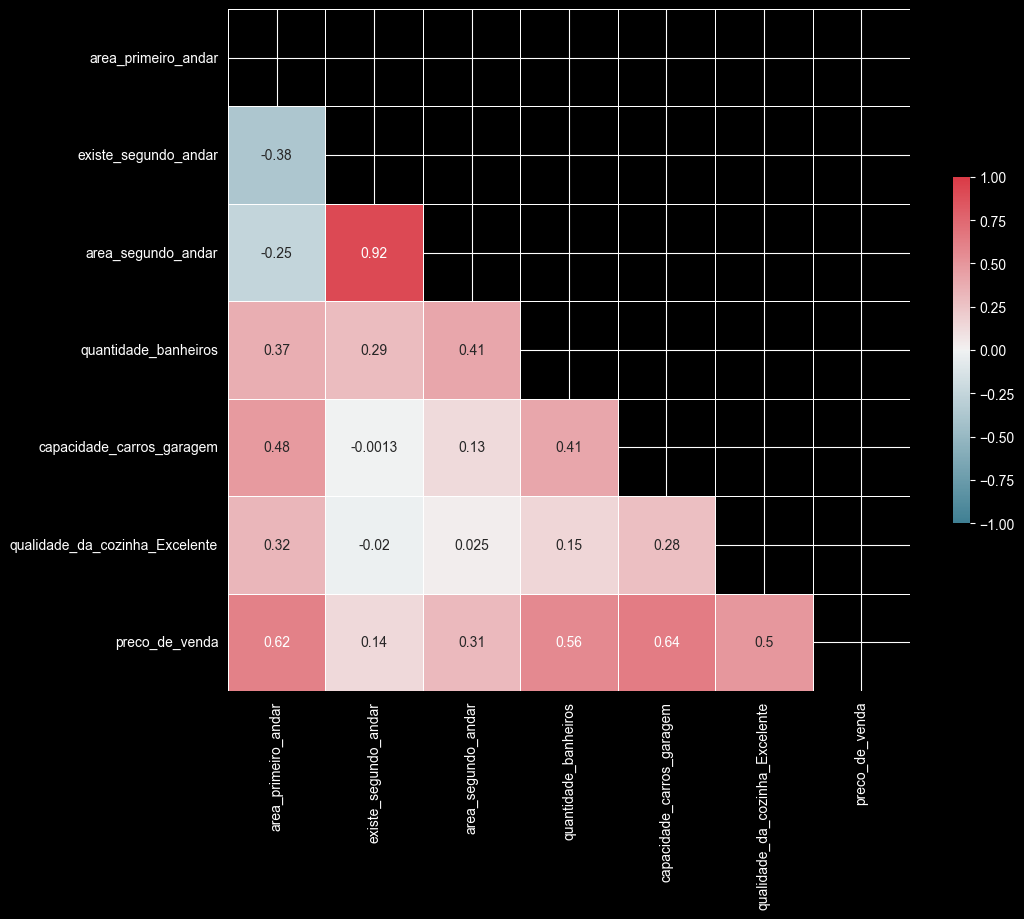

In [7]:
# Gerar mascara para o triângulo superior
mask = np.zeros_like(correlacao, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(11, 9))

# mapa de calor 
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(correlacao, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0, 
            square=True, linewidths=.5, annot=True, cbar_kws={'shrink':.5})

plt.show();

## Relacionando variáveis

In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px

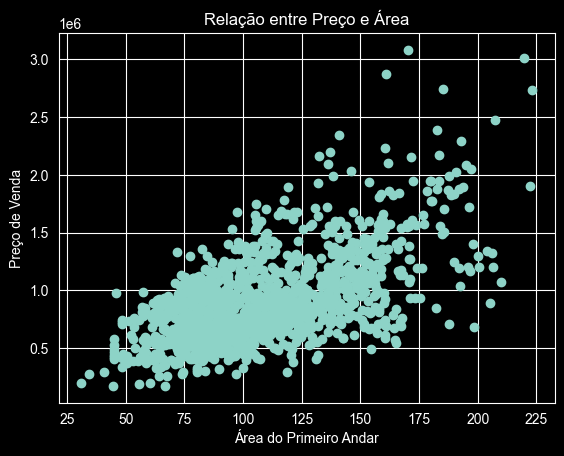

In [9]:
# Como é a relação entre área construida e o preço do imóvel? 
plt.scatter(df['area_primeiro_andar'], df['preco_de_venda'])
plt.title('Relação entre Preço e Área')
plt.xlabel('Área do Primeiro Andar')
plt.ylabel('Preço de Venda')
plt.show();

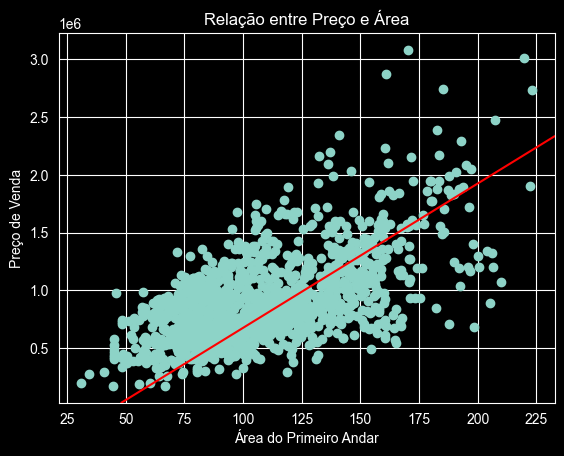

In [10]:
# E se quisermos adicionar uma linha? 
plt.scatter(df['area_primeiro_andar'], df['preco_de_venda'])
plt.axline(xy1=(66, 250000), xy2=(190, 1800000), color='red')
plt.title('Relação entre Preço e Área')
plt.xlabel('Área do Primeiro Andar')
plt.ylabel('Preço de Venda')
plt.show();

## Melhor reta

In [11]:
# Qual melhor reta que melhor se adequa a relação? 
px.scatter(df, x='area_primeiro_andar', y='preco_de_venda', 
           trendline_color_override='red', trendline='ols')

# Explicando a reta

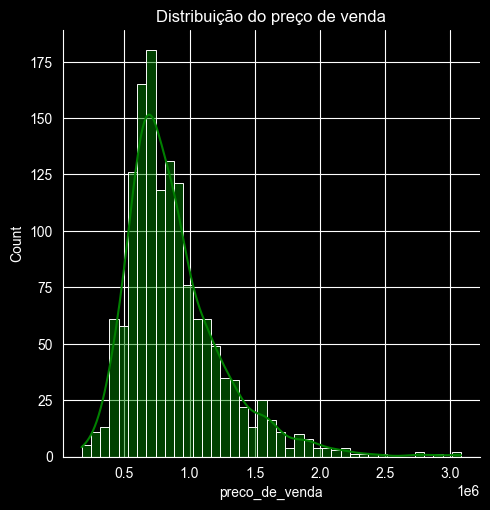

In [12]:
# Quem é nossa variável resposta? 
sns.displot(df['preco_de_venda'], kde=True, color='green')
plt.title('Distribuição do preço de venda')
plt.show();

## Separando em treino e teste

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
y = df['preco_de_venda']
X = df.drop(columns='preco_de_venda')

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=230)

In [16]:
# Dados de treino para usar a fórmula do OLS
df_train = pd.DataFrame(data=X_train)
df_train['preco_de_venda'] = y_train

In [17]:
from statsmodels.formula.api import ols

In [18]:
modelo_0 = ols(formula='preco_de_venda ~ area_primeiro_andar', data=df_train).fit()

## Analisando os coeficientes

In [19]:
# Visualizando os parâmetros
modelo_0.params

Intercept              152909.288334
area_primeiro_andar      6793.641641
dtype: float64

In [20]:
# O resumo do nosso modelo
print(modelo_0.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Wed, 14 Jan 2026   Prob (F-statistic):          2.22e-105
Time:                        14:16:01   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.529e+05   3

## Explicabilidade do modelo

In [21]:
# Observando o R²
modelo_0.rsquared

np.float64(0.3772801099429788)

## Entendendo o resíduo

In [22]:
# Quem são os resíduos: 
modelo_0.resid

1303   -193023.838744
326    -144522.356193
386     399612.747641
615     -68449.596607
236     166010.592859
            ...      
777     465872.680999
271    -497642.319788
723     461150.204718
560    -540482.733402
768     -37547.820756
Length: 1006, dtype: float64

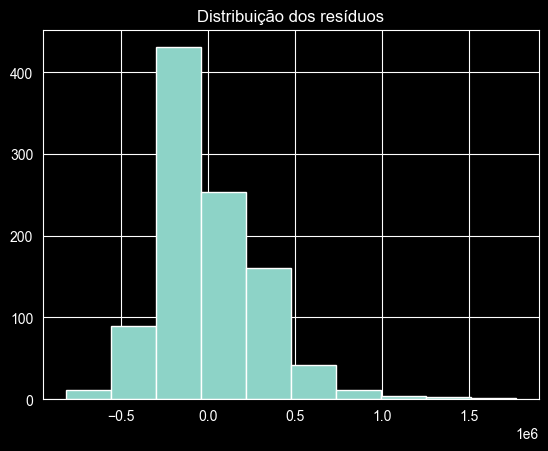

In [23]:
# Como eles estão distribuidos: 
modelo_0.resid.hist()
plt.title('Distribuição dos resíduos')
plt.show()

## Obtendo o R² da previsão

In [24]:
y_predict = modelo_0.predict(X_test)

In [25]:
from sklearn.metrics import r2_score

In [26]:
print(f'R²: {r2_score(y_test, y_predict)}')

R²: 0.38530928723202407


# Atividade da aula

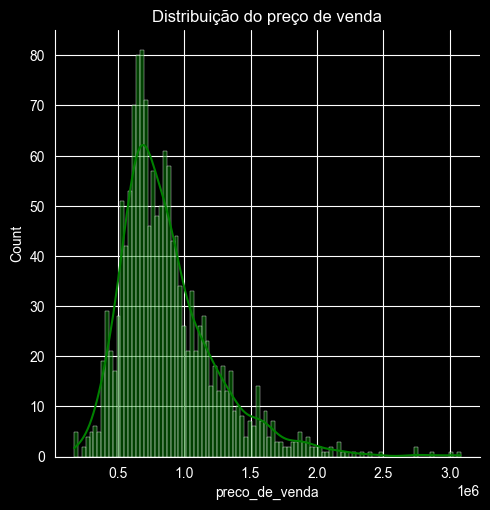

In [27]:
sns.displot(data=df, x='preco_de_venda',
            kde=True, color='green', 
            bins=100, kind='hist')
plt.title('Distribuição do preço de venda')
plt.show();

# Adicionando outras características

## Analisando os fatores

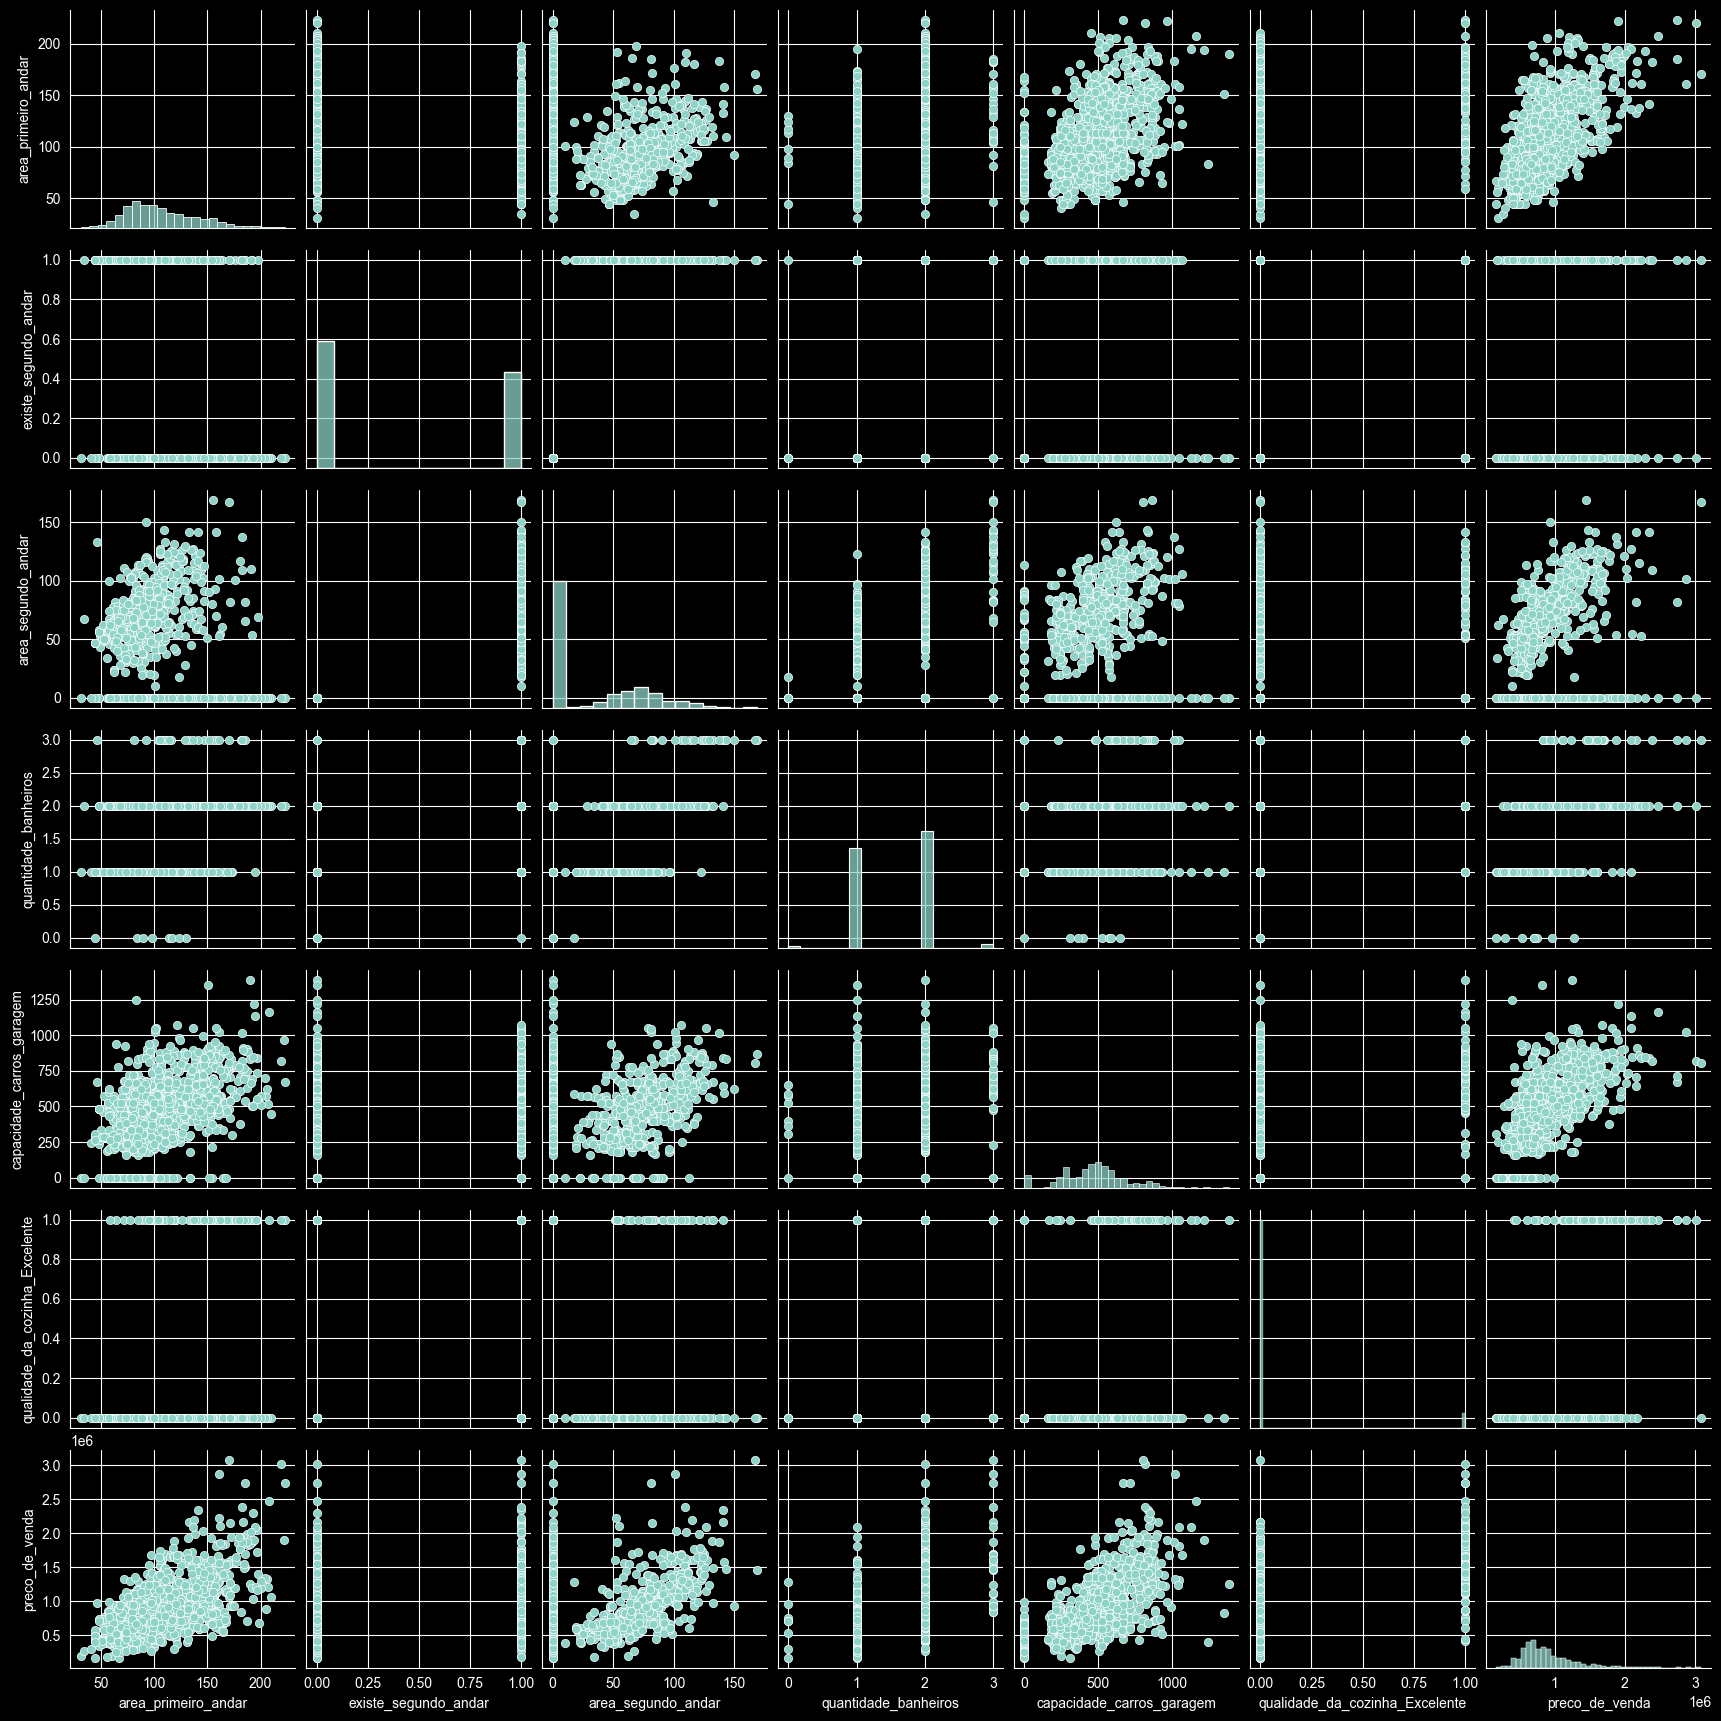

In [28]:
sns.pairplot(df)

In [29]:
df.columns

Index(['area_primeiro_andar', 'existe_segundo_andar', 'area_segundo_andar',
       'quantidade_banheiros', 'capacidade_carros_garagem',
       'qualidade_da_cozinha_Excelente', 'preco_de_venda'],
      dtype='object')

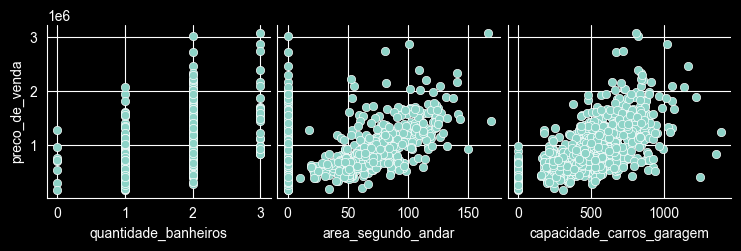

In [30]:
sns.pairplot(df, y_vars='preco_de_venda', x_vars=['quantidade_banheiros', 'area_segundo_andar', 'capacidade_carros_garagem'])

## Adicionando fatores no modelo

In [31]:
import statsmodels.api as sm

In [32]:
# Adicionando o constante
X_train = sm.add_constant(X_train)

In [33]:
X_train.head()

,const,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente
1303,1.0,65.7732,0,0.0000,1,0,0
326,1.0,55.3684,1,55.3684,1,189,0
386,1.0,74.6916,1,107.4853,2,560,0
615,1.0,103.6764,0,0.0000,1,440,0
236,1.0,94.2006,1,67.8170,2,457,0


In [34]:
X_train.columns

Index(['const', 'area_primeiro_andar', 'existe_segundo_andar',
       'area_segundo_andar', 'quantidade_banheiros',
       'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente'],
      dtype='object')

In [35]:
modelo_1 = sm.OLS(y_train, X_train[['const', 'area_primeiro_andar', 'existe_segundo_andar', 
                                   'area_segundo_andar', 'quantidade_banheiros', 'capacidade_carros_garagem', 
                                   'qualidade_da_cozinha_Excelente']]).fit()

In [36]:
modelo_2 = sm.OLS(y_train, X_train[['const', 'area_primeiro_andar', 'existe_segundo_andar', 
                                    'quantidade_banheiros', 'capacidade_carros_garagem', 
                                   'qualidade_da_cozinha_Excelente']]).fit()

In [37]:
modelo_3 = sm.OLS(y_train, X_train[['const', 'area_primeiro_andar', 'existe_segundo_andar', 
                                    'quantidade_banheiros', 'qualidade_da_cozinha_Excelente']]).fit()

In [38]:
# Resumo do modelo 1 
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     477.4
Date:                Wed, 14 Jan 2026   Prob (F-statistic):          2.79e-289
Time:                        14:16:07   Log-Likelihood:                -13640.
No. Observations:                1006   AIC:                         2.729e+04
Df Residuals:                     999   BIC:                         2.733e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [39]:
# Resumo do modelo 2
print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     485.3
Date:                Wed, 14 Jan 2026   Prob (F-statistic):          1.93e-264
Time:                        14:16:07   Log-Likelihood:                -13701.
No. Observations:                1006   AIC:                         2.741e+04
Df Residuals:                    1000   BIC:                         2.744e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [40]:
# Resumo do modelo 3
print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     467.1
Date:                Wed, 14 Jan 2026   Prob (F-statistic):          4.15e-227
Time:                        14:16:07   Log-Likelihood:                -13790.
No. Observations:                1006   AIC:                         2.759e+04
Df Residuals:                    1001   BIC:                         2.762e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## Comparando modelos

### Qual o melhor modelo? 

In [41]:
print('R²')
print(f'Modelo 0: {modelo_0.rsquared}')
print(f'Modelo 1: {modelo_1.rsquared}')
print(f'Modelo 2: {modelo_2.rsquared}')
print(f'Modelo 3: {modelo_3.rsquared}')

R²
Modelo 0: 0.3772801099429788
Modelo 1: 0.7414024156090393
Modelo 2: 0.7081440416220739
Modelo 3: 0.6511289354898803


In [42]:
# Quantos parâmetros estão no modelo? 
print(len(modelo_0.params))
print(len(modelo_1.params))
print(len(modelo_2.params))
print(len(modelo_3.params))

2
7
6
5


In [43]:
modelo_3.params

const                            -129979.678094
area_primeiro_andar                 6119.653184
existe_segundo_andar              221306.959705
quantidade_banheiros              149036.289458
qualidade_da_cozinha_Excelente    444391.228573
dtype: float64

# Precificando as casas

## Obtendo o R² da Previsão

In [47]:
X_test.columns

Index(['const', 'area_primeiro_andar', 'existe_segundo_andar',
       'area_segundo_andar', 'quantidade_banheiros',
       'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente'],
      dtype='object')

In [45]:
modelo_3.params

const                            -129979.678094
area_primeiro_andar                 6119.653184
existe_segundo_andar              221306.959705
quantidade_banheiros              149036.289458
qualidade_da_cozinha_Excelente    444391.228573
dtype: float64

In [46]:
# Adicionando uma constante em X_test
X_test = sm.add_constant(data=X_test)

In [48]:
# Prevendo com o modelo 3
predict_3 = modelo_3.predict(X_test[['const', 'area_primeiro_andar', 'existe_segundo_andar',
                         'quantidade_banheiros', 'qualidade_da_cozinha_Excelente']])

In [49]:
# Qual o R² da previsão?
modelo_3.rsquared

np.float64(0.6511289354898803)

In [50]:
# Qual o R² do treino?
print(f'R²: {r2_score(y_test, predict_3)}')

R²: 0.6432078074497707


In [51]:
# Novo imovel
novo_imovel = pd.DataFrame({
    'const': [1],
    'area_primeiro_andar': [120],
    'existe_segundo_andar': [1],
    'quantidade_banheiros': [2],
    'qualidade_da_cozinha_Excelente': [0]
})

In [52]:
# Qual o preço desse imóvel com o modelo 0 ?
modelo_0.predict(novo_imovel['area_primeiro_andar'])

0    968146.285305
dtype: float64

In [55]:
# Qual o preço desse imóvel com o modelo 3?
print(modelo_3.predict(novo_imovel)[0])

1123758.2426020517


# Precificando várias casas

In [56]:
# Lendo várias casas?
uri_casas = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\Novas_casas.csv'
novas_casas = pd.read_csv(uri_casas, sep=';')
novas_casas.head()

,Casa,area_primeiro_andar,existe_segundo_andar,quantidade_banheiros,qualidade_da_cozinha_Excelente
0,1,150,1,2,1
1,2,180,0,3,1
2,3,120,1,2,1
3,4,200,1,3,1
4,5,160,0,2,1


In [58]:
novas_casas.drop(columns='Casa', inplace=True)
novas_casas.head()

,area_primeiro_andar,existe_segundo_andar,quantidade_banheiros,qualidade_da_cozinha_Excelente
0,150,1,2,1
1,180,0,3,1
2,120,1,2,1
3,200,1,3,1
4,160,0,2,1


In [59]:
# Adicionando constante
novas_casas = sm.add_constant(data=novas_casas)

In [61]:
novas_casas.head()

,const,area_primeiro_andar,existe_segundo_andar,quantidade_banheiros,qualidade_da_cozinha_Excelente
0,1.0,150,1,2,1
1,1.0,180,0,3,1
2,1.0,120,1,2,1
3,1.0,200,1,3,1
4,1.0,160,0,2,1


In [62]:
# Qual o preço dessas novas casas?
modelo_3.predict(novas_casas)

0    1.751739e+06
1    1.863058e+06
2    1.568149e+06
3    2.206758e+06
4    1.591629e+06
5    1.246151e+06
6    1.357470e+06
7    1.552134e+06
8    9.636478e+05
9    1.639974e+06
dtype: float64

## Atividade

In [63]:
novo_imovel2 = pd.DataFrame({
    'const': [1],
    'area_primeiro_andar': [98],
    'existe_segundo_andar': [0],
    'quantidade_banheiros': [1],
    'qualidade_da_cozinha_Excelente': [1]
})

In [64]:
print(modelo_3.predict(novo_imovel2)[0])

1063173.8519646404


# Salvando o modelo com a biblioteca Pickle

In [65]:
import pickle
nome_arquivo = 'modelo_regressao_linear.pkl'
with open(nome_arquivo, 'wb') as arquivo:
    pickle.dump(modelo_3, arquivo)

In [66]:
with open(nome_arquivo, 'rb') as arquivo:
    modelo_carregado = pickle.load(arquivo)

In [68]:
modelo_carregado.params

const                            -129979.678094
area_primeiro_andar                 6119.653184
existe_segundo_andar              221306.959705
quantidade_banheiros              149036.289458
qualidade_da_cozinha_Excelente    444391.228573
dtype: float64

# Multicolinearidade

In [69]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [70]:
explicativas_1 = ['const','area_primeiro_andar', 'existe_segundo_andar',
       'area_segundo_andar', 'quantidade_banheiros',
       'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente']

explicativas_2 = ['const','area_primeiro_andar', 'existe_segundo_andar',
       'quantidade_banheiros', 'capacidade_carros_garagem',
       'qualidade_da_cozinha_Excelente']

explicativas_3 = ['const','area_primeiro_andar', 'existe_segundo_andar',
       'quantidade_banheiros', 'qualidade_da_cozinha_Excelente']

In [71]:
# VIF 1
vif_1 = pd.DataFrame()
vif_1['variavel'] = explicativas_1

vif_1['vif'] = [variance_inflation_factor(X_train[explicativas_1], i) for i in range(len(explicativas_1))]

In [72]:
vif_1

,variavel,vif
0,const,20.230833
1,area_primeiro_andar,2.193680
2,existe_segundo_andar,7.455059
3,area_segundo_andar,7.589396
4,quantidade_banheiros,1.720795
5,capacidade_carros_garagem,1.570078
6,qualidade_da_cozinha_Excelente,1.182606


In [74]:
# VIF 3
vif_3 = pd.DataFrame()
vif_3['variavel'] = explicativas_3

vif_3['vif'] = [variance_inflation_factor(X_train[explicativas_3], i) for i in range(len(explicativas_3))]

In [75]:
vif_3

,variavel,vif
0,const,18.773457
1,area_primeiro_andar,1.919046
2,existe_segundo_andar,1.644067
3,quantidade_banheiros,1.539255
4,qualidade_da_cozinha_Excelente,1.151795


## Análise de resíduos

In [76]:
# Prevendo os valores do treino X_train[explicativas_3]
y_previsto_train = modelo_3.predict(X_train[explicativas_3])


In [78]:
# Fazendo um scatter plot entre y_previsto e y_train
fig = px.scatter(x=y_previsto_train,
                 y=y_train,
                 title='Previsão X Real', labels={'x': 'Preço Previsto', 'y': 'Preço Real'}, )

fig.show();

In [79]:
# Residuos
residuos = modelo_3.resid

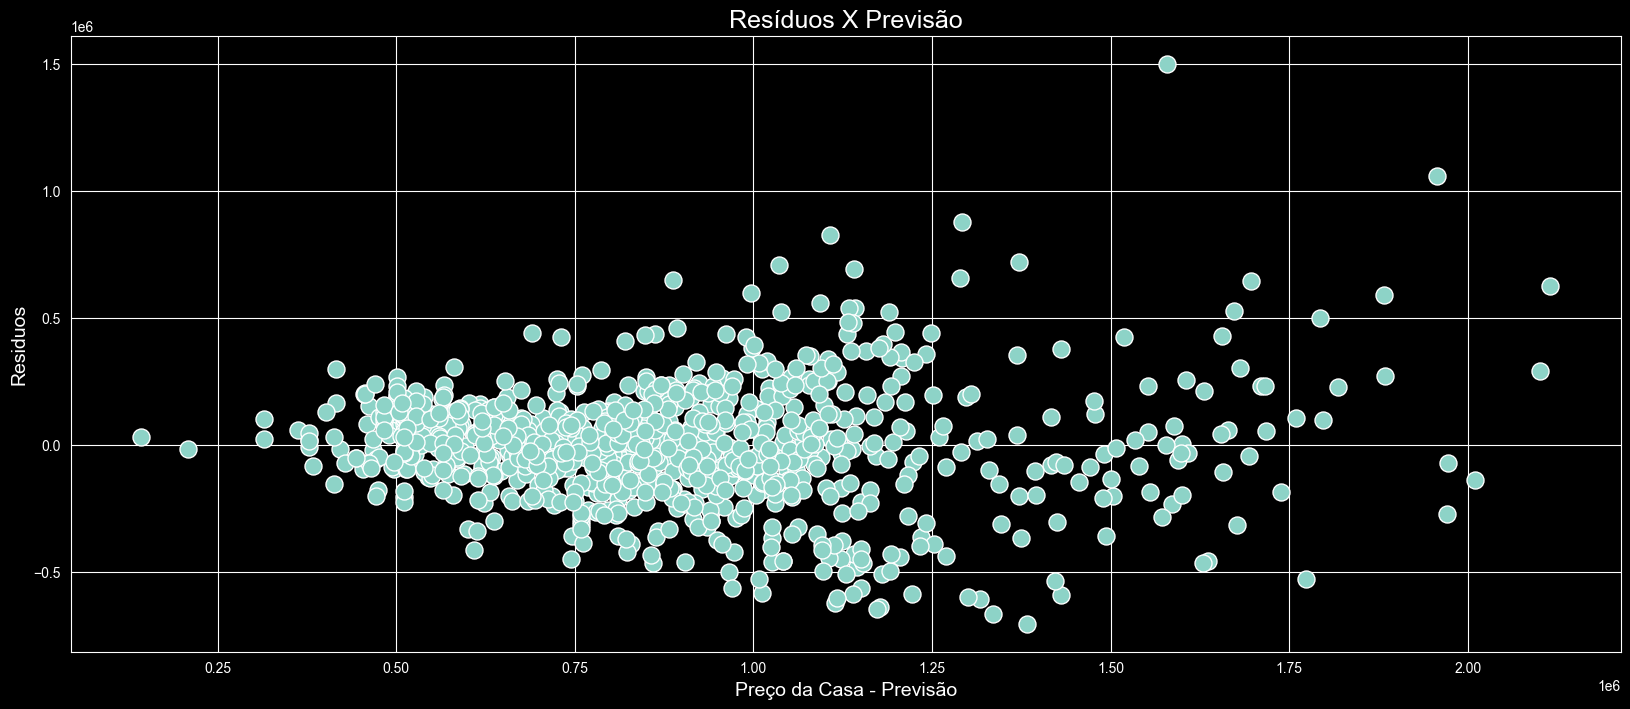

In [80]:
ax = sns.scatterplot(x=y_previsto_train, y=residuos, s=150)
ax.figure.set_size_inches(20, 8)
ax.set_title('Resíduos X Previsão', fontsize=18)
ax.set_xlabel('Preço da Casa - Previsão', fontsize=14)
ax.set_ylabel('Residuos', fontsize=14)
ax;